In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

In [2]:
# try multiple known sources for the Advertising dataset - read the dataframe
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url, index_col=0)

In [3]:
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [5]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Quick observations from the summary:
All four columns are numeric (float64) — no encoding needed.
There are no missing values, which is convenient.
TV budgets vary a lot (0.7 to 296.4), while Newspaper budgets are more moderate.
Sales range from about 1.6 to 27 thousand units.

EDA STARTS

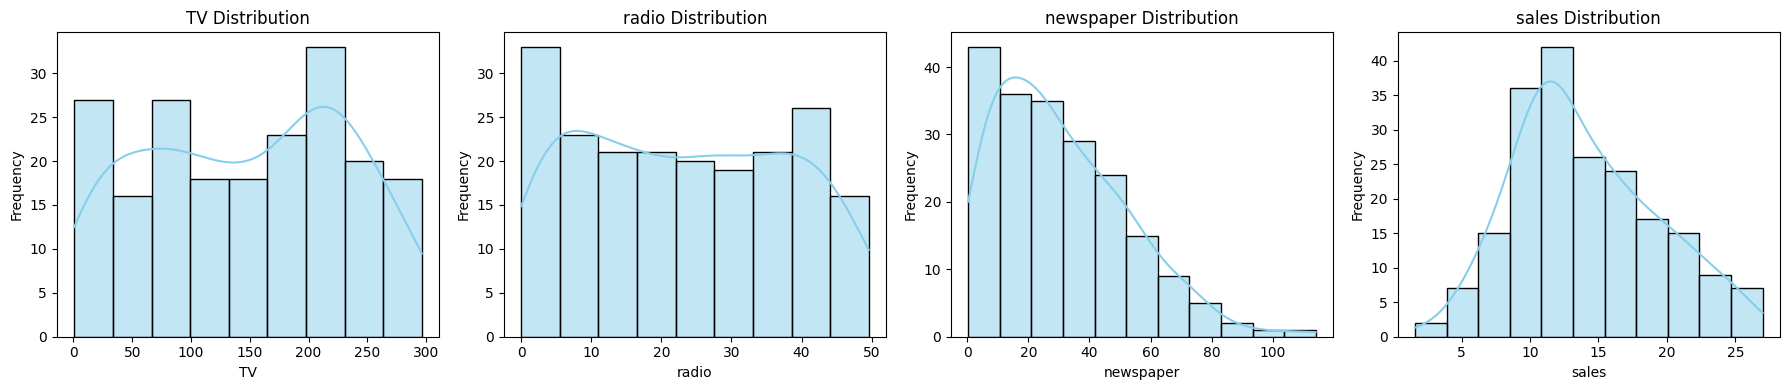

In [6]:
# histograms with KDE for each feature to check distribution shape and potential outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Simple Inference from the Histograms
TV: Advertising spending is spread widely, from about $0–$300k.
Radio: Spending ranges from about $0–$50k and is fairly spread out.
Newspaper: Most spending is below $50k, with a few observations going up to $110k+.
Sales: Most sales are around 10–15 thousand units.
Overall: The graphs show how frequently different advertising spending amounts and sales levels occur.

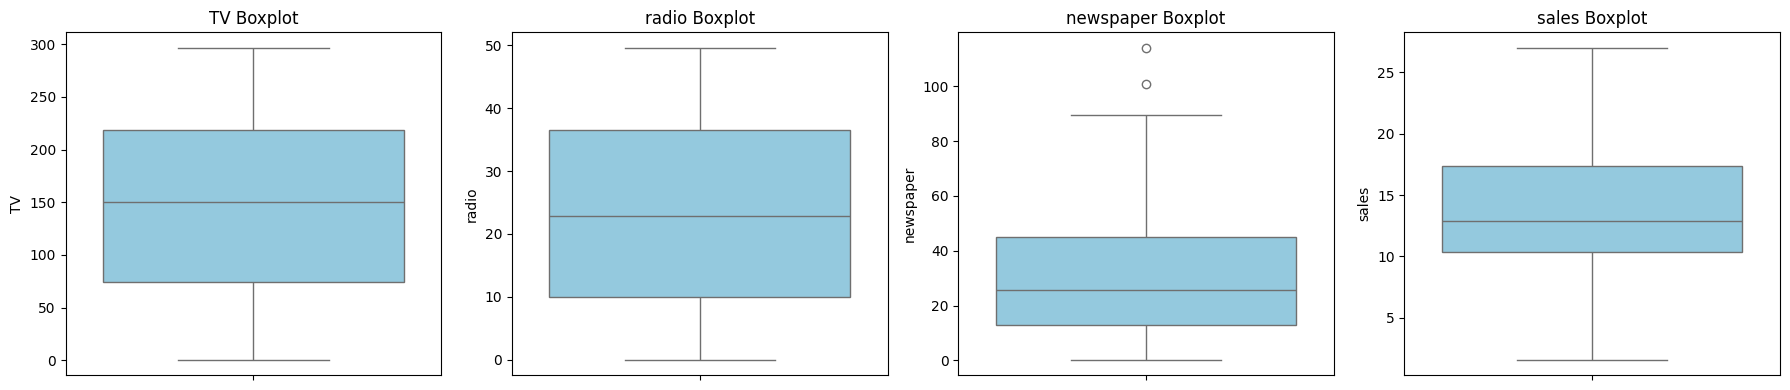

In [7]:
# boxplots to check for outliers and distribution shape
fig, axes = plt.subplots(1,4, figsize=(18,4))

for i,col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Boxplot Observations
TV: Spending is widely distributed from $0–$300k, with no major outliers.
Radio: Spending ranges from $0–$50k, with no major outliers.
Newspaper: Most spending is below $50k, but there are 2 high-value outliers around $100k–$115k.
Sales: Most sales are between 10–18 thousand units, with no major outliers.
Overall: The dataset is generally clean, with potential outliers mainly in Newspaper spending.

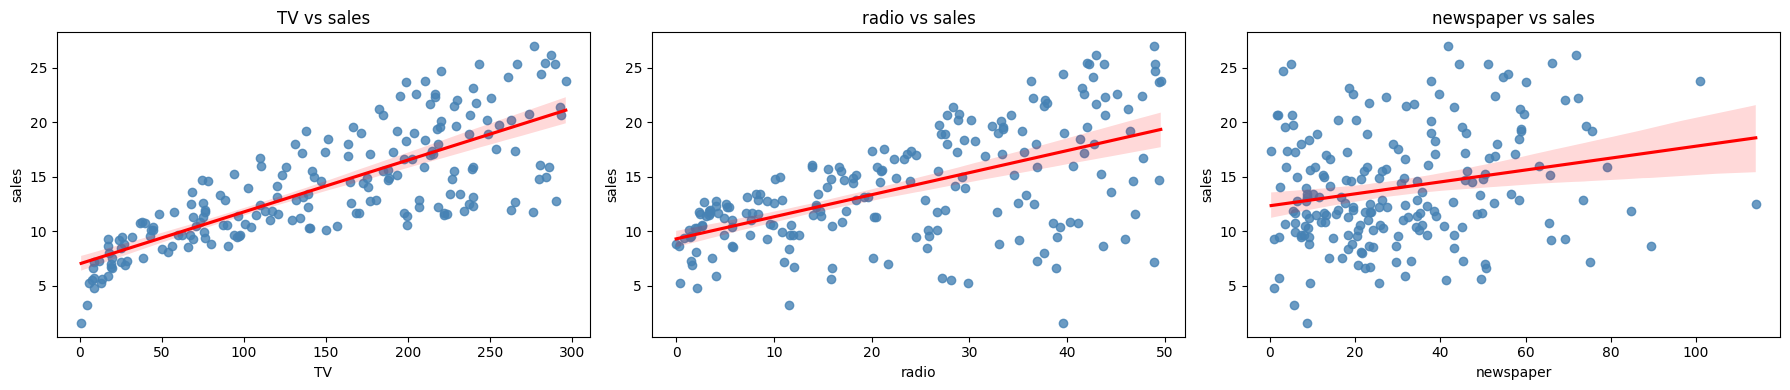

In [8]:
# scatter plots with regression lines for each feature vs target
features = df.columns[:-1]  # all columns except the last one (Sales)
target = df.columns[-1]     # the last column (Sales)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, feature in enumerate(features):
    sns.regplot(x=df[feature], y=df[target], ax=axes[i], color='steelblue', line_kws={'color':'red'})
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

Simple observations from the Scatter Plots
TV vs Sales: Strong positive relationship — as TV advertising spending increases, sales generally increase.
Radio vs Sales: Positive relationship — higher radio spending generally corresponds to higher sales, but the points are more spread out.
Newspaper vs Sales: Weak positive relationship — increasing newspaper spending does not clearly lead to higher sales.
Overall: TV appears to have the clearest relationship with Sales, while Newspaper has a much weaker relationship.

              TV  radio  newspaper  sales
TV         1.000  0.055      0.057  0.782
radio      0.055  1.000      0.354  0.576
newspaper  0.057  0.354      1.000  0.228
sales      0.782  0.576      0.228  1.000


<Axes: >

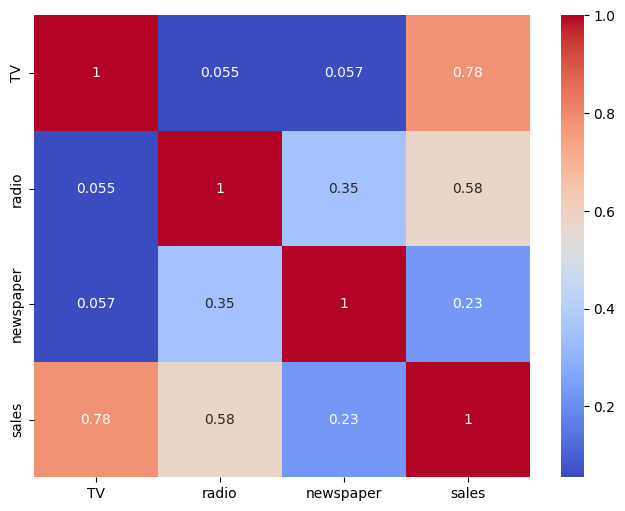

In [10]:
corr=df.corr().round(3)
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')


TV has the strongest correlation with Sales (0.782), followed by Radio (0.576), while Newspaper has a weak correlation (0.228).

This tells us that TV and Radio are likely to be more useful predictors of Sales in our regression model.

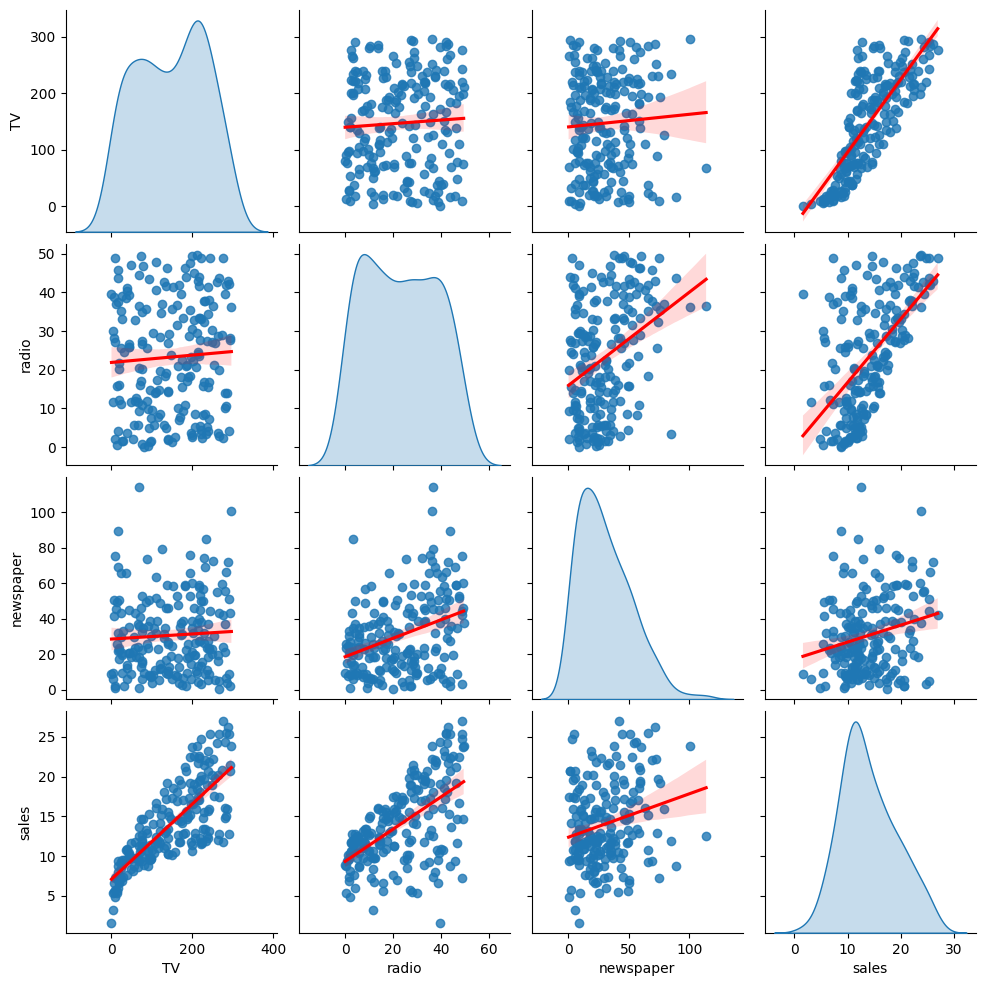

In [11]:
# pairplot for a comprehensive view of all bivariate relationships
sns.pairplot(df, kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})

Simple Insights from Pairplot
TV vs Sales: Strong positive relationship → more TV spending generally means higher sales.
Radio vs Sales: Moderate positive relationship → radio spending also helps increase sales.
Newspaper vs Sales: Weak relationship → newspaper spending has less clear impact on sales.
TV, Radio, Newspaper: They don't have very strong relationships with each other.
Main takeaway: TV is the strongest-looking predictor of Sales, followed by Radio.

In [15]:
X=df[['TV','radio','newspaper']]
y=df['sales']

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [18]:
# create the Linear Regression model
model = LinearRegression()

In [19]:
# train the model
model.fit(X_train, y_train)

LinearRegression()

In [20]:
# make predictions on test data
y_pred = model.predict(X_test)

In [21]:
print("Actual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(y_pred)

Actual Sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9 11.  12.8
 10.1  9.7 11.6  7.6 10.5 14.6 10.4 12.  14.6 11.7  7.2  6.6  9.4 11.
 10.9 25.4  7.6 11.7]

Predicted Sales:
[16.5653963  21.18822792 21.55107058 10.88923816 22.20231988 13.35556872
 21.19692502  7.35028523 13.27547079 15.12449511  9.01443026  6.52542825
 14.30205991  8.97026042  9.45679576 12.00454351  8.91549403 16.15619251
 10.29582883 18.72473553 19.76821818 13.77469028 12.49638908 21.53501762
  7.60860741  5.6119801  20.91759483 11.80627665  9.08076637  8.51412012
 12.17604891  9.9691939  21.73008956 12.77770578 18.1011362  20.07590796
 14.26202556 20.93826535 10.83938827  4.38190607  9.51332406 12.40486324
 10.17045434  8.09081363 13.16388427  5.2243552   9.28893833 14.09330719
  8.69024497 11.66119763 15.71848432 11.63156862 13.35360735 11.1531472
  6.336

In [23]:
# Multiple LR -- Test set performance
y_pred = model.predict(X_test)

mse_mlr = mean_squared_error(y_test, y_pred)
r2_mlr = r2_score(y_test, y_pred)
mae_mlr = mean_absolute_error(y_test, y_pred)

# print all the metrics together for easy comparison
print("--- Multiple LR -- Test set performance ---")
print(f"R-squared : {r2_mlr:.4f}")
print(f"MAE       : {mae_mlr:.4f}")
print(f"RMSE      : {np.sqrt(mse_mlr):.4f}")

--- Multiple LR -- Test set performance ---
R-squared : 0.8609
MAE       : 1.5117
RMSE      : 1.9485


R² = 0.8609
The model explains about 86.09% of the variation in Sales.
So the three advertising variables together explain a large portion of the differences in sales.
MAE = 1.5117
On average, the prediction is off by about 1.51 thousand units of sales.
Since Sales is measured in thousands of units, that's roughly 1,512 units.
RMSE = 1.9485
Typical prediction error is around 1.95 thousand units.
RMSE is higher than MAE because it gives more weight to larger errors.

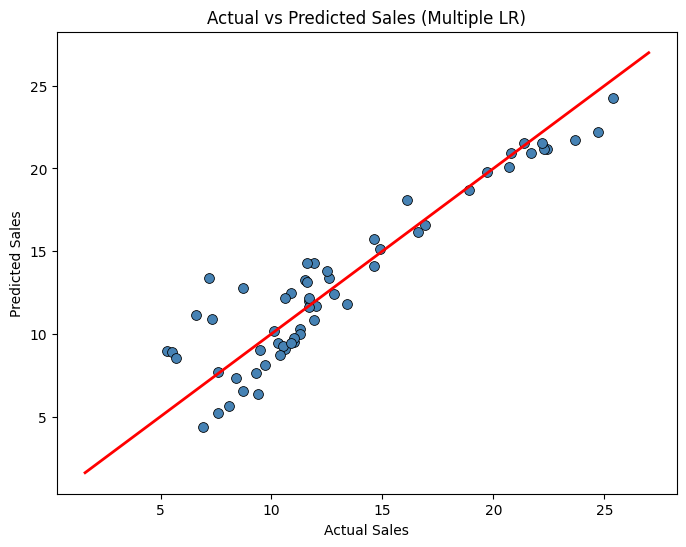

In [24]:
# Actual vs Predicted Sales (Multiple LR) plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color='steelblue',
    edgecolor='black',
    s=50
)

sns.lineplot(
    x=[y.min(), y.max()],
    y=[y.min(), y.max()],
    color='red',
    linewidth=2
)

plt.title('Actual vs Predicted Sales (Multiple LR)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

Simple conclusion for your project
Most points are reasonably close to the red line.
Therefore, the model's predictions are reasonably close to actual sales.
Some points are farther away, meaning the model makes larger errors for some observations.
This visually supports the R² = 0.8609 result we obtained earlier.

/tmp/ipykernel_712/1226436572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns, y=model.coef_, palette='viridis')


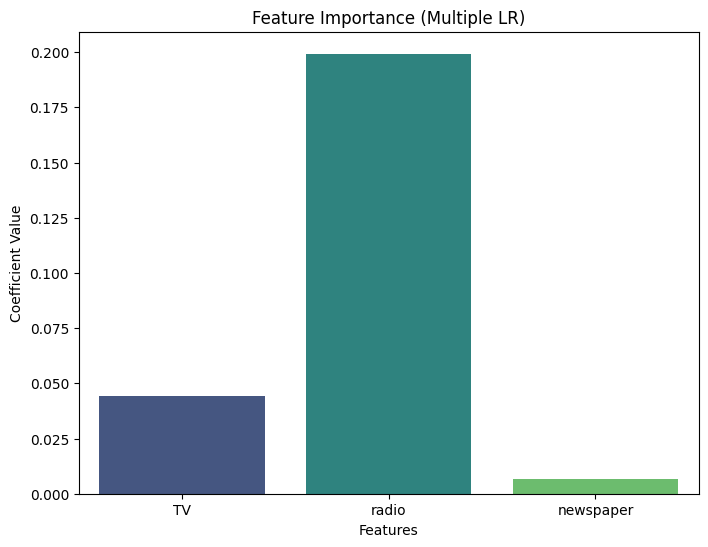

In [26]:
# coefficient bar chart plot to visually compare the relative importance of each feature
plt.figure(figsize=(8,6))
sns.barplot(x=X.columns, y=model.coef_, palette='viridis')
plt.title('Feature Importance (Multiple LR)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.show()

TV advertising: Higher TV spending is strongly associated with higher sales, so TV appears to be an important sales-driving channel.
Radio advertising: Radio has the largest per-unit coefficient in this model, suggesting additional radio spending is associated with a relatively large increase in predicted sales, holding other channels constant.
Newspaper advertising: Its coefficient is very small, suggesting limited additional contribution to predicted sales after accounting for TV and Radio.
Budget strategy: The business should evaluate TV and Radio spending more closely when planning advertising budgets rather than assuming all channels contribute equally.
Important: These are model-based associations, not proof that increasing spending will directly cause the same increase in sales.